# BNCI2014-001 with MOABB and Braindecode

Read the existing local cache at `data/moabb/MNE-bnci-data` using Braindecode's standard workflow: `MOABBDataset` → preprocessing → event windows → session split → PyTorch `DataLoader`. The dataset is BCI Competition IV 2a: nine subjects and four motor-imagery classes.

In [1]:
import os
from pathlib import Path

import braindecode
import matplotlib.pyplot as plt
import mne
import moabb
import numpy as np
from IPython.display import display
from braindecode.datasets import MOABBDataset
from braindecode.preprocessing import (
    Preprocessor,
    create_windows_from_events,
    exponential_moving_standardize,
    preprocess,
)
from torch.utils.data import DataLoader

print('Braindecode:', braindecode.__version__)
print('MOABB:', moabb.__version__)
print('MNE:', mne.__version__)

Braindecode: 1.7.0
MOABB: 1.5.0
MNE: 1.12.1


## Point MOABB to the local BNCI cache

MOABB expects the parent directory of `MNE-bnci-data`. The environment variable makes it reuse the local files rather than download another copy.

In [2]:
def find_moabb_root(start=Path.cwd()):
    for directory in (start.resolve(), *start.resolve().parents):
        candidate = directory / 'data' / 'moabb'
        bnci_files = candidate / 'MNE-bnci-data' / '~bci' / 'database' / '001-2014'
        if (bnci_files / 'A01T.mat').is_file():
            return candidate
    raise FileNotFoundError(
        'Could not find data/moabb/MNE-bnci-data. '
        'Start Jupyter from within the EEG repository.'
    )

MOABB_ROOT = find_moabb_root()
os.environ['MNE_DATASETS_BNCI_PATH'] = str(MOABB_ROOT)
print('Using local BNCI data:', MOABB_ROOT / 'MNE-bnci-data')

Using local BNCI data: /workspaces/EEG/data/moabb/MNE-bnci-data


## Load BNCI2014-001 through Braindecode

Choose subject numbers from 1 to 9. Subject 1 contains six training runs and six test runs.

In [3]:
SUBJECT_IDS = [1]

dataset = MOABBDataset(
    dataset_name='BNCI2014_001',
    subject_ids=SUBJECT_IDS,
)

print('Recordings:', len(dataset.datasets))
display(dataset.description)

first_recording = dataset.datasets[0].raw
print(first_recording)
print('Channel types:', dict(zip(*np.unique(first_recording.get_channel_types(), return_counts=True))))
print('Annotations:', dict(zip(*np.unique(first_recording.annotations.description, return_counts=True))))

Recordings: 12


,subject,session,run
0,1,0train,0
1,1,0train,1
2,1,0train,2
3,1,0train,3
4,1,0train,4
5,1,0train,5
6,1,1test,0
7,1,1test,1
8,1,1test,2
9,1,1test,3


<RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>
Channel types: {np.str_('eeg'): np.int64(22), np.str_('eog'): np.int64(3), np.str_('stim'): np.int64(1)}
Annotations: {np.str_('feet'): np.int64(12), np.str_('left_hand'): np.int64(12), np.str_('right_hand'): np.int64(12), np.str_('tongue'): np.int64(12)}


## Verify the complete raw recording

This overview shows every channel across the complete first training run, before preprocessing. Each trace is independently normalized by its 99th-percentile absolute amplitude only for display; the raw data are unchanged.

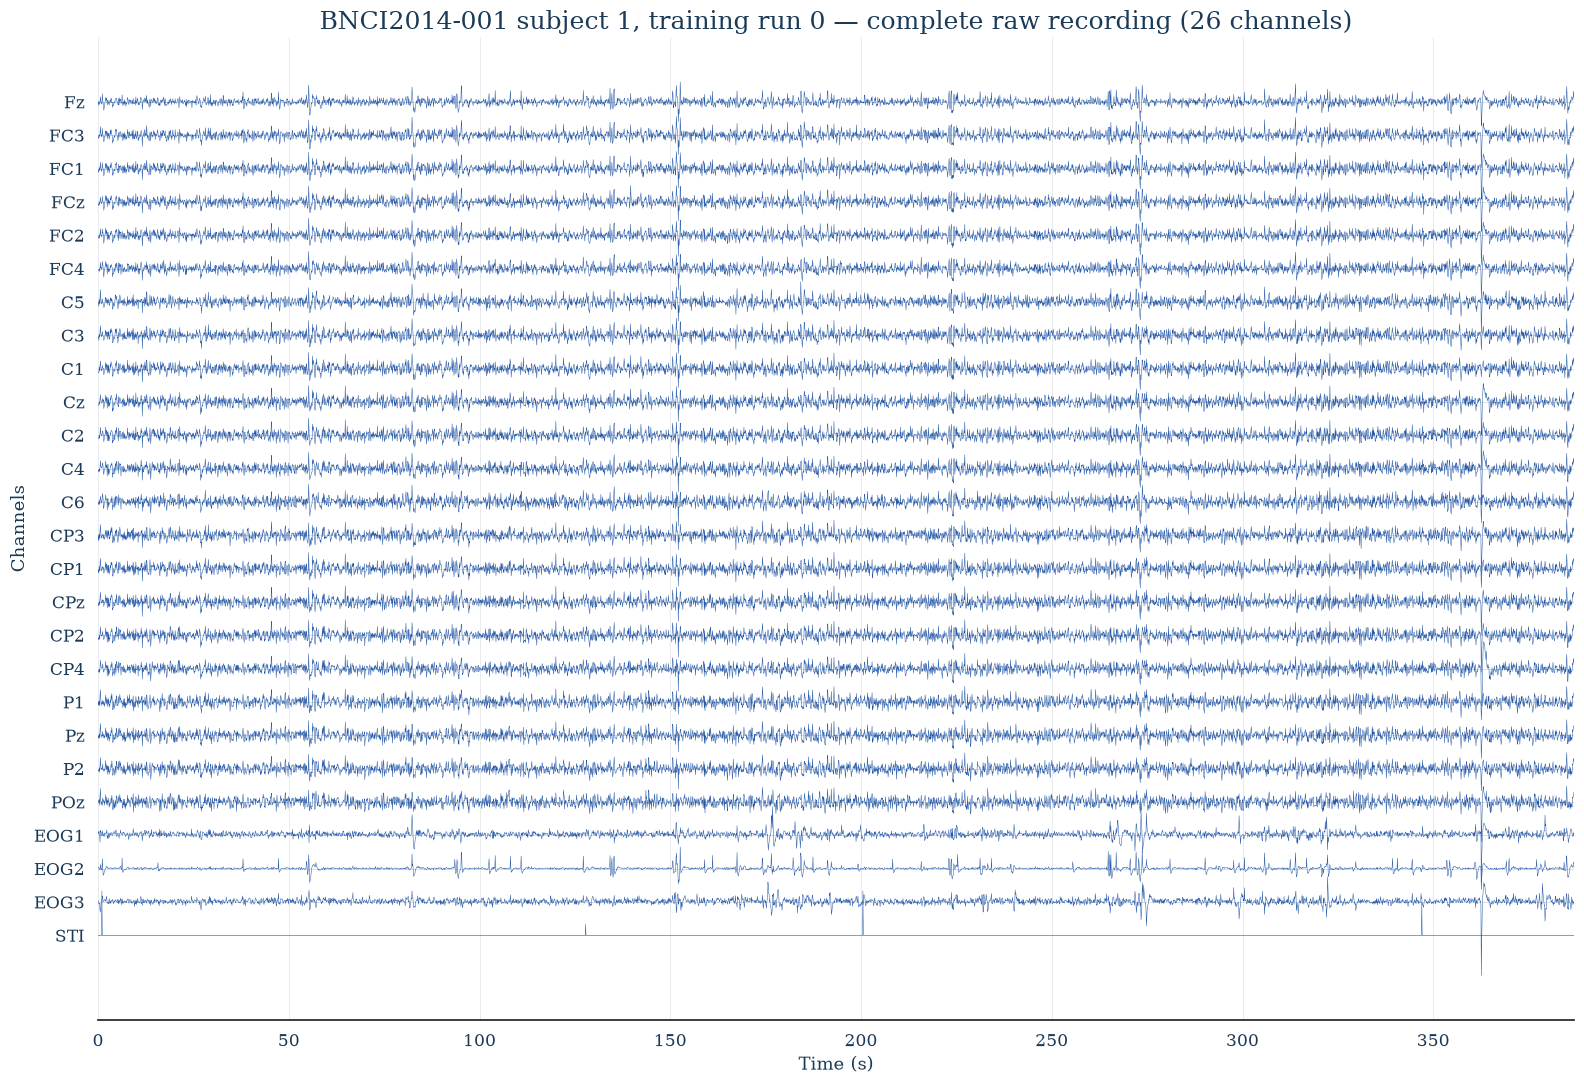

In [4]:
# Downsample only the plotted points to keep the full recording readable.
display_step = max(1, int(first_recording.info['sfreq'] // 10))
display_data = first_recording.get_data()[:, ::display_step]
display_times = first_recording.times[::display_step]
display_scale = np.nanpercentile(np.abs(display_data), 99, axis=1, keepdims=True)
display_scale[display_scale == 0] = 1
display_positions = np.arange(len(first_recording.ch_names))[::-1] * 3

fig, ax = plt.subplots(figsize=(16, 11))
ax.plot(
    display_times,
    (display_data / display_scale + display_positions[:, None]).T,
    linewidth=0.35,
    color='#2457a6',
)
ax.set_yticks(display_positions, first_recording.ch_names)
ax.set(
    xlim=(display_times[0], display_times[-1]),
    xlabel='Time (s)',
    ylabel='Channels',
    title=(f'BNCI2014-001 subject {SUBJECT_IDS[0]}, training run 0 — '
           f'complete raw recording ({len(first_recording.ch_names)} channels)'),
)
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()


## Standard Braindecode preprocessing

Keep the 22 EEG channels, apply a 4–38 Hz motor-imagery band-pass filter, retain the native 250 Hz sampling frequency, and apply exponential moving standardization.

In [ ]:
preprocessors = [
    Preprocessor('pick', picks='eeg', apply_on_array=False),
    Preprocessor('filter', l_freq=4.0, h_freq=38.0, apply_on_array=False),
    Preprocessor(
        exponential_moving_standardize,
        factor_new=1e-3,
        init_block_size=1000,
    ),
]

preprocess(dataset, preprocessors, n_jobs=1)
processed_raw = dataset.datasets[0].raw
print(processed_raw)
print('EEG channels:', len(processed_raw.ch_names))
print('Sampling frequency:', processed_raw.info['sfreq'], 'Hz')

## Create four-second motor-imagery windows

MOABB maps the classes to integer targets: left hand = 0, right hand = 1, feet = 2, and tongue = 3.

In [ ]:
windows_dataset = create_windows_from_events(
    dataset,
    trial_start_offset_samples=0,
    trial_stop_offset_samples=0,
    preload=True,
)

X, y, window_info = windows_dataset[0]
print('Total trials:', len(windows_dataset))
print('One trial shape (channels, samples):', X.shape)
print('First target:', y)
print('Window indices [trial, start, stop]:', window_info)
display(windows_dataset.description)

## Use the original train/test sessions

BNCI2014-001 provides separate training and evaluation sessions. Keeping this split avoids leakage between runs from the two sessions.

In [ ]:
session_splits = windows_dataset.split('session')
train_set = session_splits['0train']
test_set = session_splits['1test']

print('Training trials:', len(train_set))
print('Test trials:', len(test_set))

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

X_batch, y_batch, window_info_batch = next(iter(train_loader))
print('Batch X shape:', tuple(X_batch.shape))
print('Batch y shape:', tuple(y_batch.shape))
print('Model settings:')
print('  n_chans =', X_batch.shape[1])
print('  n_times =', X_batch.shape[2])
print('  n_outputs = 4')